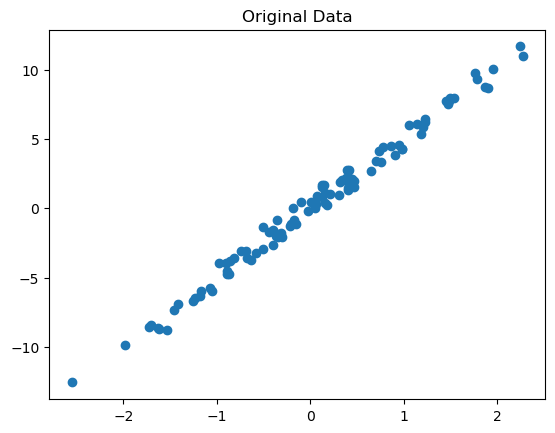

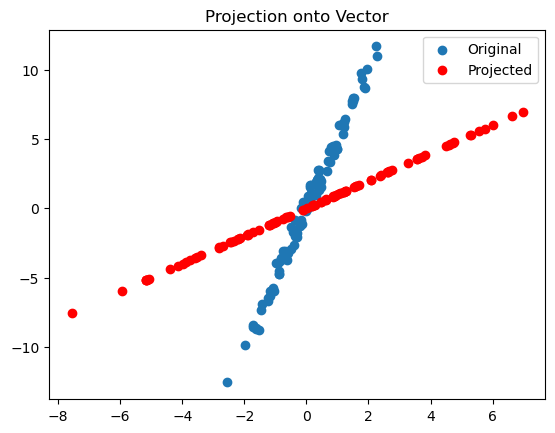

Original Variance: 13.650480740067202
Projected Variance: 18.7682372862533


In [12]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(0)
x = np.random.randn(100)
y = 5*x + np.random.randn(100)*0.5
data = np.vstack((x, y)).T


plt.scatter(data[:,0], data[:,1])
plt.title("Original Data")
plt.show()


v = np.array([1, 1])
v = v / np.linalg.norm(v)


projection = data @ v
projected_points = np.outer(projection, v)

plt.scatter(data[:,0], data[:,1], label='Original')
plt.scatter(projected_points[:,0], projected_points[:,1], color='red', label='Projected')
plt.legend()
plt.title("Projection onto Vector")
plt.show()

print("Original Variance:", np.var(data))
print("Projected Variance:", np.var(projection))

#max Variance - First Prinicipal Component

Eigenvalues: [9.95116935e-03 2.75271141e+01]
Eigenvectors:
 [[-0.98136264 -0.19216494]
 [ 0.19216494 -0.98136264]]


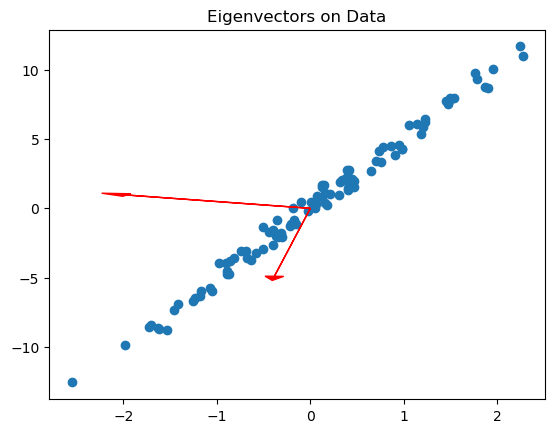

In [13]:
cov = np.cov(data.T)
eigvals, eigvecs = np.linalg.eig(cov)

print("Eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)

# Plot eigenvectors
plt.scatter(data[:,0], data[:,1])

for i in range(2):
    plt.arrow(0, 0, eigvecs[0,i]*2, eigvecs[1,i]*5,
              color='red', head_width=0.2)

plt.title("Eigenvectors on Data")
plt.show()

#Largest eigenvalue → maximum variance
#Eigenvector → direction of that variance

In [14]:

mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
X = (data - mean) / std


cov = np.cov(X.T)


eigvals, eigvecs = np.linalg.eig(cov)


idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]


k = 1
W = eigvecs[:, :k]


X_reduced = X @ W
print(X_reduced[:5])

[[2.49609123]
 [0.37499142]
 [1.18553319]
 [3.09664908]
 [2.42922014]]


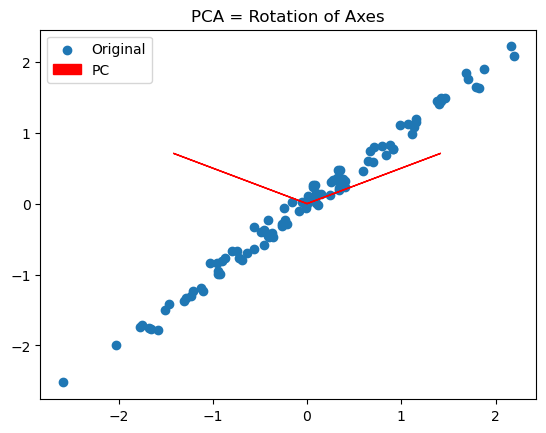

In [15]:
plt.scatter(X[:,0], X[:,1], label='Original')

for i in range(2):
    plt.arrow(0,0,eigvecs[0,i]*2,eigvecs[1,i]*1,
              color='red', label='PC' if i==0 else "")

plt.legend()
plt.title("PCA = Rotation of Axes")
plt.show()

#PCA rotates axes so data aligns with maximum variance directions.

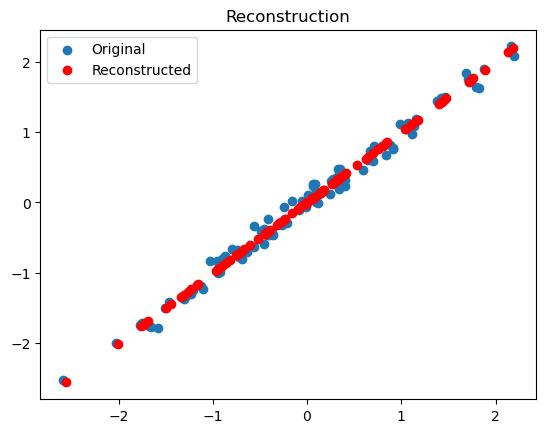

In [16]:
# Reduce to 1D
W1 = eigvecs[:, :1]
X1 = X @ W1

# Reconstruct
X_reconstructed = X1 @ W1.T

plt.scatter(X[:,0], X[:,1], label='Original')
plt.scatter(X_reconstructed[:,0], X_reconstructed[:,1], color='red', label='Reconstructed')
plt.legend()
plt.title("Reconstruction")
plt.show()

#Lost information = variance in removed dimensions.

In [17]:
# Different scale data
x = np.random.rand(100)*100
y = np.random.rand(100)

data = np.vstack((x,y)).T

# PCA without scaling
cov = np.cov(data.T)
eigvals1, eigvecs1 = np.linalg.eig(cov)

# With scaling
X = (data - np.mean(data,axis=0)) / np.std(data,axis=0)
cov = np.cov(X.T)
eigvals2, eigvecs2 = np.linalg.eig(cov)

print("Without scaling:", eigvecs1)
print("With scaling:", eigvecs2)

#Scaling ensures all features contribute equally.

Without scaling: [[ 9.99999948e-01  3.22289293e-04]
 [-3.22289293e-04  9.99999948e-01]]
With scaling: [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


In [18]:
explained_variance_ratio = eigvals / np.sum(eigvals)
print(explained_variance_ratio)

[0.99747616 0.00252384]


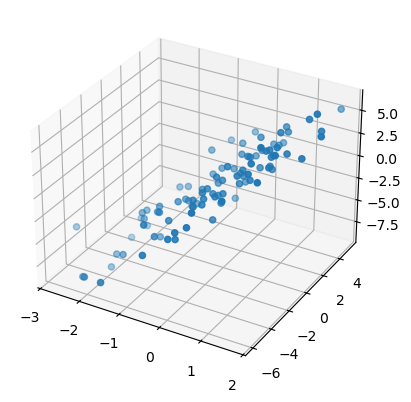

In [19]:
from mpl_toolkits.mplot3d import Axes3D

# 3D data
x = np.random.randn(100)
y = 2*x + np.random.randn(100)
z = x + y + np.random.randn(100)

data3D = np.vstack((x,y,z)).T

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x,y,z)
plt.show()

In [20]:
original_size = data.nbytes
reduced_size = X_reduced.nbytes

print("Original size:", original_size)
print("Reduced size:", reduced_size)

#PCA Reduces size along with some data of original form

Original size: 1600
Reduced size: 800


In [21]:
#1. What does PCA optimize?
#→ Maximum variance.

#2. Why variance = information?
#→ More spread = more useful patterns.

#3. No correlation?
#→ PCA not useful.

#4. Why standardize?
#→ Avoid domination by large-scale features.

#5. Covariance vs correlation?
#→ Covariance: scale-dependent
#→ Correlation: normalized

#6. PCA & projection?
#→ Data projected onto new axes.

#7. Why orthogonal?
#→ Avoid redundancy.

#8. Rotation meaning?
#→ Changing coordinate system.

#9. Reduce redundancy?
#→ Combines correlated features.

#10. Easy to interpret?
#→ Not always.

#11. Negative loading?
#→ Opposite relationship.

#12. Highly correlated features?
#→ Combined into one component.

#13. 90% variance?
#→ Most info in one component.

#14. Uses labels?
#→ No (unsupervised).

#15. When avoid PCA?
#→ When interpretation matters.

#16. Always improve performance?
#→ No.

#17. Equal variance, no correlation?
#→ No reduction.

#18. One large-scale feature?
#→ Dominates PCA.

#19. Nonlinear data?
#→ PCA fails (linear method).

#20. Classification issues?
#→ Ignores class labels.